# HUST Gearbox Dataset

-   Paper: https://www.sciencedirect.com/science/article/pii/S0951832024000395
-   GitHub: https://github.com/CHAOZHAO-1/HUSTgearbox-dataset
-   Google Drive (w/ data): https://drive.google.com/drive/folders/1Lt8Xu6NICPadliXhOtDMB683uKwZv4FP

**ERRORS**

-   H_35_4.txt - Acceleration from 0 instead of steady state


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px

from signal_analysis import FFT_TSA, order_track_FFT, order_track_signal, signal_TSA
import matplotlib.pyplot as plt

## Processing


In [29]:
sampling_rate = 25600  # Hz
pinion_teeth = 18
fault_map = {
    "H": "healthy",
    "B": "broken_tooth",
    "M": "missing_tooth",
}

# OT

# 25000 Hz (sampling rate) / 40 Hz (max speed) = 640, so must be under that
# 18 * 30 = 540
num_samples_per_revolution = pinion_teeth * 30

# TSA
revolutions_per_TSA = 40
TSA_step_size = 5


# Raw data
data_folder = (
    Path.cwd().parent.parent.parent / "data" / "HUST_gearbox" / "raw data"
)  # Notice space in "raw data"
files = data_folder.glob("**/*.txt")

df_rows = []
for f in files:
    p = f.stem.split("_")

    if len(p) != 3:
        continue
    print(p)

    # Specs
    fault = p[0]
    speed = int(p[1])
    load = int(p[2])

    df = pd.read_csv(
        f,
        delimiter="\t",
        names=["time", "tacho", "acc_x", "acc_y", "acc_z"],
        skiprows=18,
    )

    # Tacho
    cleaned_pulses = (df["tacho"] > 3) * 1  # clean (* 1 to ensure int, not boolean)
    crossing_idxs = np.where(np.diff(cleaned_pulses) == 1)[0]

    # Check if real speed matches the one in the filename
    rot_freq = sampling_rate / np.diff(crossing_idxs)
    wrong_speed_mask = ~(rot_freq < speed + 0.2) & (rot_freq > speed - 0.2)
    if np.sum(wrong_speed_mask) > 0:
        print(rot_freq)
        print(f"Speed does not match ({speed} vs {np.mean(rot_freq)}) in {f.parts}")

    angle = np.arange(len(crossing_idxs)) * 360
    # ! Endings are incorrect because of extrapolation, but they get cut out
    interpolated_angle = np.interp(np.arange(len(df["tacho"])), crossing_idxs, angle)

    # Signal OT
    ##

    # OT
    accx_OT_signal = order_track_signal(
        df["acc_x"],
        np.arange(len(df["acc_x"])) / sampling_rate,
        interpolated_angle,
        num_samples_per_revolution=num_samples_per_revolution,
    )
    accy_OT_signal = order_track_signal(
        df["acc_y"],
        np.arange(len(df["acc_y"])) / sampling_rate,
        interpolated_angle,
        num_samples_per_revolution=num_samples_per_revolution,
    )
    accz_OT_signal = order_track_signal(
        df["acc_z"],
        np.arange(len(df["acc_z"])) / sampling_rate,
        interpolated_angle,
        num_samples_per_revolution=num_samples_per_revolution,
    )

    # Cut ends (one full revolution on both sides) because of extrapolation
    accx_OT_signal = accx_OT_signal[
        1 * num_samples_per_revolution : -1 * num_samples_per_revolution
    ]
    accy_OT_signal = accy_OT_signal[
        1 * num_samples_per_revolution : -1 * num_samples_per_revolution
    ]
    accz_OT_signal = accz_OT_signal[
        1 * num_samples_per_revolution : -1 * num_samples_per_revolution
    ]

    # TSA
    accx_OT_TSA = signal_TSA(
        accx_OT_signal,
        num_samples_per_revolution,
        revolutions_per_TSA,
        TSA_step_size,
    )
    accy_OT_TSA = signal_TSA(
        accy_OT_signal,
        num_samples_per_revolution,
        revolutions_per_TSA,
        TSA_step_size,
    )
    accz_OT_TSA = signal_TSA(
        accz_OT_signal,
        num_samples_per_revolution,
        revolutions_per_TSA,
        TSA_step_size,
    )

    # FFT
    accx_signal_OT_samples = np.abs(np.fft.rfft(accx_OT_TSA, norm="forward", axis=1))[
        :, : 11 * pinion_teeth
    ]
    accy_signal_OT_samples = np.abs(np.fft.rfft(accy_OT_TSA, norm="forward", axis=1))[
        :, : 11 * pinion_teeth
    ]
    accz_signal_OT_samples = np.abs(np.fft.rfft(accz_OT_TSA, norm="forward", axis=1))[
        :, : 11 * pinion_teeth
    ]

    accx_signal_OT_samples = accx_signal_OT_samples.astype(np.float32)
    accy_signal_OT_samples = accy_signal_OT_samples.astype(np.float32)
    accz_signal_OT_samples = accz_signal_OT_samples.astype(np.float32)

    # Check that all sensors have the same number of samples
    # If not, something is probably wrong
    if (
        accx_signal_OT_samples.shape[0] != accy_signal_OT_samples.shape[0]
        and accx_signal_OT_samples.shape[0] != accz_signal_OT_samples.shape[0]
    ):
        raise ValueError(
            "Different numbers of signal OT samples for accx, accy, and accz."
        )

    # Explode rows
    for i in range(accx_signal_OT_samples.shape[0]):
        df_rows.append(
            {
                "fault": fault,
                "speed": speed,
                "load": load,
                "OT_method": "signal",
                "accx": accx_signal_OT_samples[i],
                "accy": accy_signal_OT_samples[i],
                "accz": accz_signal_OT_samples[i],
            }
        )

    # FFT OT
    ##

    # OT & FFT
    accx_OT_FFT = order_track_FFT(
        df["acc_x"], None, interpolated_angle, num_orders=pinion_teeth * 11
    )
    accy_OT_FFT = order_track_FFT(
        df["acc_y"], None, interpolated_angle, num_orders=pinion_teeth * 11
    )
    accz_OT_FFT = order_track_FFT(
        df["acc_z"], None, interpolated_angle, num_orders=pinion_teeth * 11
    )

    # Cut ends (one full revolution on both sides) because of extrapolation
    accx_OT_FFT = accx_OT_FFT[1:-1]
    accy_OT_FFT = accy_OT_FFT[1:-1]
    accz_OT_FFT = accz_OT_FFT[1:-1]

    # TSA
    accx_fft_OT_samples = FFT_TSA(
        accx_OT_FFT,
        revolutions_per_TSA,
        TSA_step_size,
    )
    accy_fft_OT_samples = FFT_TSA(
        accy_OT_FFT,
        revolutions_per_TSA,
        TSA_step_size,
    )
    accz_fft_OT_samples = FFT_TSA(
        accz_OT_FFT,
        revolutions_per_TSA,
        TSA_step_size,
    )

    accx_fft_OT_samples = accx_fft_OT_samples.astype(np.float32)
    accy_fft_OT_samples = accy_fft_OT_samples.astype(np.float32)
    accz_fft_OT_samples = accz_fft_OT_samples.astype(np.float32)

    # Check that all sensors have the same number of samples
    # If not, something is probably wrong
    if (
        accx_fft_OT_samples.shape[0] != accy_fft_OT_samples.shape[0]
        and accx_fft_OT_samples.shape[0] != accz_fft_OT_samples.shape[0]
    ):
        raise ValueError(
            "Different numbers of FFT OT samples for accx, accy, and accz."
        )

    # Explode rows
    for i in range(accx_fft_OT_samples.shape[0]):
        df_rows.append(
            {
                "fault": fault,
                "speed": speed,
                "load": load,
                "OT_method": "fft",
                "accx": accx_fft_OT_samples[i],
                "accy": accy_fft_OT_samples[i],
                "accz": accz_fft_OT_samples[i],
            }
        )

df = pd.DataFrame(df_rows)
df.head(3)

['B', '30', '1']
['M', '25', '4']
['M', '40', '1']
['H', '30', '2']
['H', '30', '3']
['M', '40', '0']
['B', '30', '0']
['B', '30', '2']
['M', '40', '2']
['H', '30', '1']
['H', '30', '0']
['M', '40', '3']
['B', '30', '3']
['M', '25', '2']
['H', '30', '4']
['M', '25', '3']
['B', '30', '4']
['M', '25', '1']
['M', '40', '4']
['M', '25', '0']
['M', '20', '3']
['M', '20', '2']
['M', '20', '0']
['B', '35', '4']
['M', '20', '1']
['B', '35', '0']
['H', '35', '3']
['H', '35', '2']
['B', '35', '1']
['M', '20', '4']
['B', '35', '3']
['H', '35', '0']
['H', '35', '1']
['B', '35', '2']
['H', '20', '0']
['B', '20', '3']
['B', '20', '2']
['H', '20', '1']
['H', '20', '3']
['B', '20', '0']
['M', '35', '4']
['B', '20', '1']
['H', '20', '2']
['M', '35', '0']
['M', '35', '1']
['B', '20', '4']
['M', '35', '3']
['M', '35', '2']
['H', '20', '4']
['B', '40', '1']
['M', '30', '1']
['B', '25', '4']
['H', '40', '2']
['H', '40', '3']
['M', '30', '0']
['B', '40', '0']
['B', '40', '2']
['H', '25', '4']
['M', '30', '2

,fault,speed,load,OT_method,accx,accy,accz
0,B,30,1,signal,"[0.018750815, 0.0011436222, 0.000110473964, 6....","[0.013526907, 0.000666232, 4.3007658e-05, 1.66...","[0.0142746605, 0.0012497033, 0.0001395682, 9.1..."
1,B,30,1,signal,"[0.01874285, 0.0011467354, 0.00016985815, 5.01...","[0.013487813, 0.00065709377, 4.3062533e-05, 2....","[0.014300961, 0.0012407467, 0.0001386706, 8.76..."
2,B,30,1,signal,"[0.018708374, 0.001149595, 0.00016617237, 0.00...","[0.013474745, 0.00066817633, 4.162168e-05, 2.1...","[0.0142762475, 0.0012544678, 0.00013800355, 2...."


In [30]:
df.dtypes

fault        object
speed         int64
load          int64
OT_method    object
accx         object
accy         object
accz         object
dtype: object

In [31]:
# SAVING

df.to_feather(Path.cwd().parent.parent / "data" / "HUST_gearbox_OT.feather")

## Testing


In [139]:
data_folder = (
    Path.cwd().parent.parent.parent / "data" / "HUST_gearbox" / "raw data"
)  # Notice space in "raw data"
sample_file = data_folder / "B_35_0.txt"

df = pd.read_csv(
    sample_file,
    delimiter="\t",
    names=["time", "tacho", "acc_x", "acc_y", "acc_z"],
    skiprows=18,
)
df

,time,tacho,acc_x,acc_y,acc_z
0,0.000000,5.003922,-0.059685,-0.206398,0.130181
1,0.000039,5.004430,-0.071824,-0.210093,0.044995
2,0.000078,5.001019,-0.041914,-0.009457,0.049034
3,0.000117,5.002742,-0.017965,0.184836,-0.044049
4,0.000156,5.005065,0.023828,0.263614,-0.202765
...,...,...,...,...,...
262139,1.279805,0.062720,0.041902,0.075236,-0.052576
262140,1.279844,0.059104,0.070149,0.081859,-0.132635
262141,1.279883,0.062941,0.096199,0.095415,-0.119902
262142,1.279922,0.064188,0.089068,0.096930,-0.048897


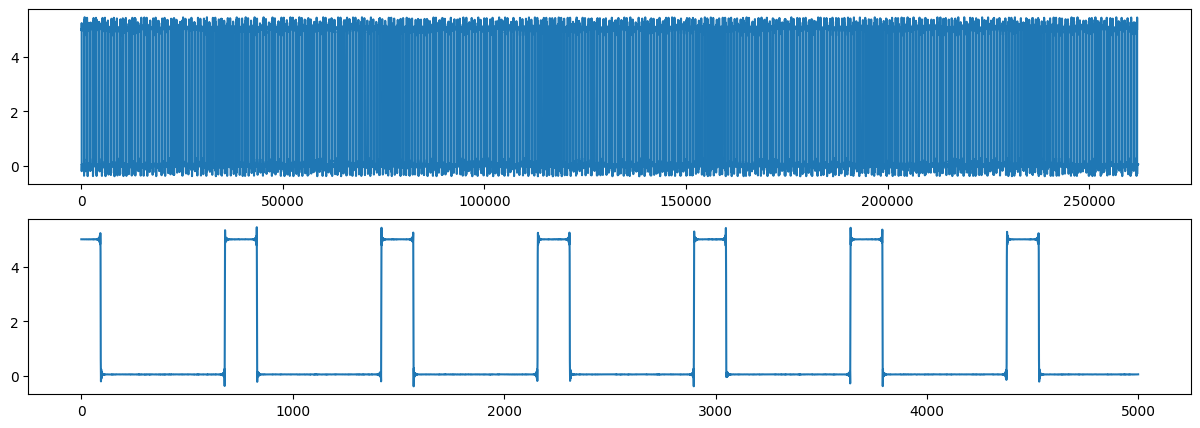

In [140]:
fig, ax = plt.subplots(2, 1, figsize=(15, 5))
ax[0].plot(df["tacho"])
ax[1].plot(df["tacho"][:5000])

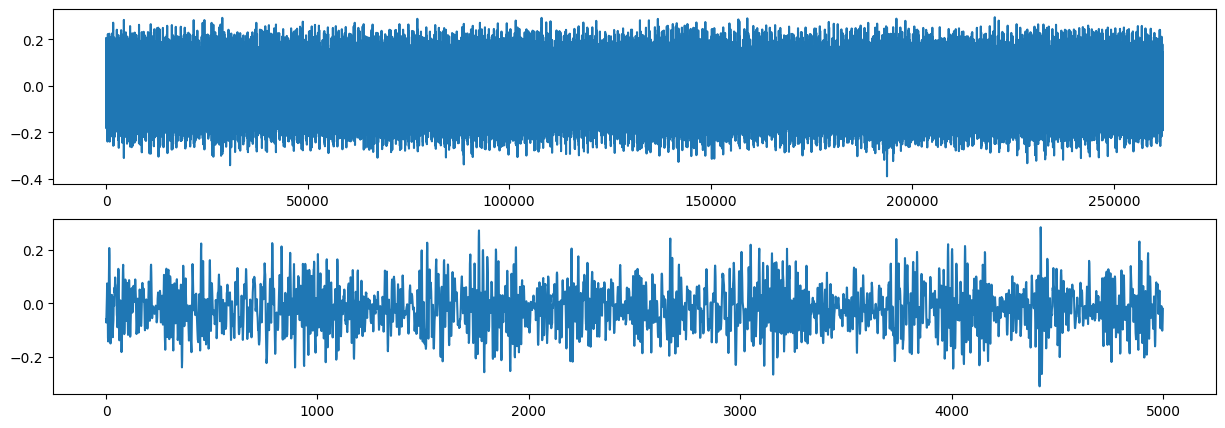

In [141]:
fig, ax = plt.subplots(2, 1, figsize=(15, 5))
ax[0].plot(df["acc_x"])
ax[1].plot(df["acc_x"][:5000])

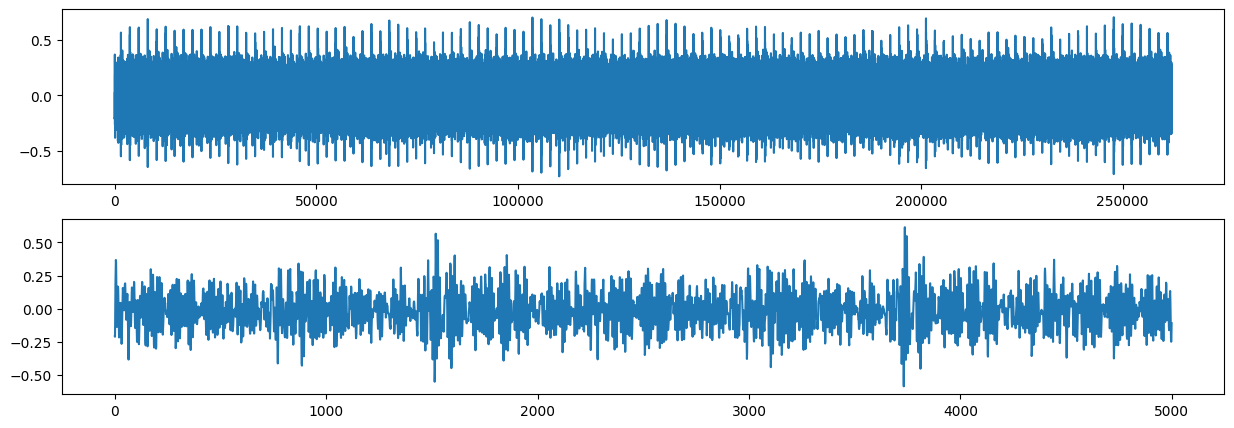

In [142]:
fig, ax = plt.subplots(2, 1, figsize=(15, 5))
ax[0].plot(df["acc_y"])
ax[1].plot(df["acc_y"][:5000])

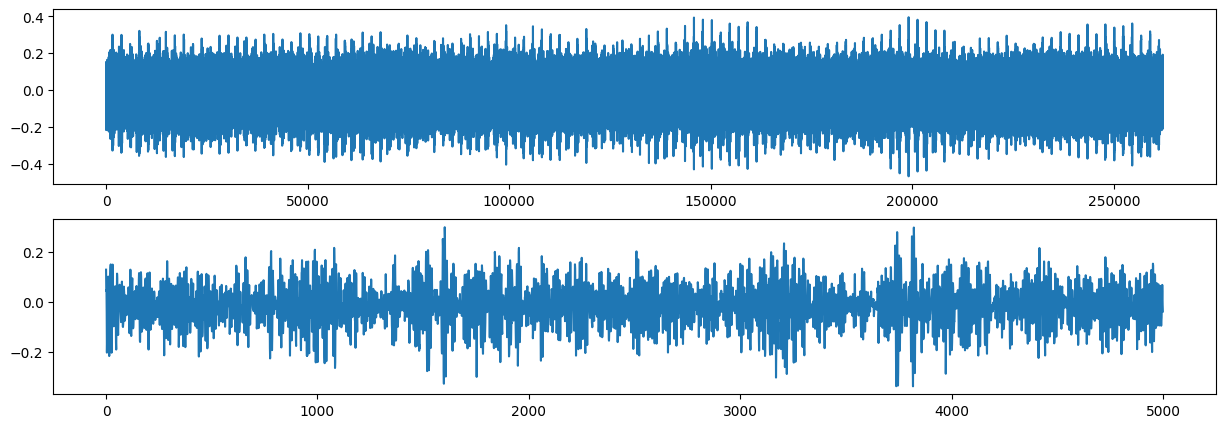

In [143]:
fig, ax = plt.subplots(2, 1, figsize=(15, 5))
ax[0].plot(df["acc_z"])
ax[1].plot(df["acc_z"][:5000])

In [146]:
# Tacho
cleaned_pulses = (df["tacho"] > 3) * 1  # clean (* 1 to ensure int, not boolean)
crossing_idxs = np.where(np.diff(cleaned_pulses) == 1)[0]
angle = np.arange(len(crossing_idxs)) * 360
interpolated_angle = np.interp(np.arange(len(df["tacho"])), crossing_idxs, angle)

# Signal OT
accx_OT_signal = order_track_signal(
    df["acc_x"],
    np.arange(len(df["acc_x"])) / sampling_rate,
    interpolated_angle,
    num_samples_per_revolution=num_samples_per_revolution,
)

# Cut ends (one full revolution on both sides)
accx_OT_signal = accx_OT_signal[
    1 * num_samples_per_revolution : -1 * num_samples_per_revolution
]

# TSA
accx_OT_TSA = signal_TSA(
    accx_OT_signal,
    num_samples_per_revolution,
    revolutions_per_TSA,
    TSA_step_size,
)

# FFT
accx_signal_OT_samples = np.abs(np.fft.rfft(accx_OT_TSA, norm="forward", axis=1))[
    :, : 11 * pinion_teeth
]

px.line(accx_signal_OT_samples[1][1:])